# Exercise 1

## 1.1 Data Exploration

### Q1.1.1

In [23]:
%pip install ucimlrepo

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from ucimlrepo import fetch_ucirepo

superconductivity_data = fetch_ucirepo(id=464)

data = pd.concat(
    [superconductivity_data.data.features,
     superconductivity_data.data.targets],
    axis=1
)

data.head()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.0


In [25]:
summary = data.describe().T

features = summary.drop("critical_temp")

display(features.sort_values("std", ascending=False).head(5))



,count,mean,std,min,25%,50%,75%,max
range_Density,21263.0,8665.438818,4097.126831,0.000000,6648.000000,8958.571000,9778.571000,22588.571
wtd_gmean_Density,21263.0,3117.241110,3975.122587,0.686245,66.746836,1515.364631,5766.015191,22590.000
gmean_Density,21263.0,3460.692235,3703.256370,1.429000,883.117278,1339.974702,5794.965188,22590.000
wtd_mean_Density,21263.0,5267.188547,3221.314506,1.429000,2999.158291,4303.421500,6416.333333,22590.000
mean_Density,21263.0,6111.465214,2846.785185,1.429000,4513.500000,5329.085800,6728.000000,22590.000


The future that shows the highest variation are:


1.   `range_Density`
2.   `wtd_gmean_Density`
3.   `gmean_Density`
4.   `wtd_mean_Density`
5.   `mean_Density`


Comparing raw standard deviations across the features can be misleading. Say if we had measured something and used the unit meter, then we would have 1 meter but if we hade used centimeters we would have 100 cm. They are the same lengths but different units and the centimeter feature would have a higher std then the feature which emasures it in meters.

A more suitbable measurement would be coefficent of variation.
$$
\text{CV} = \frac{\text{std}}{\text{mean}}
$$

### Q1.1.2

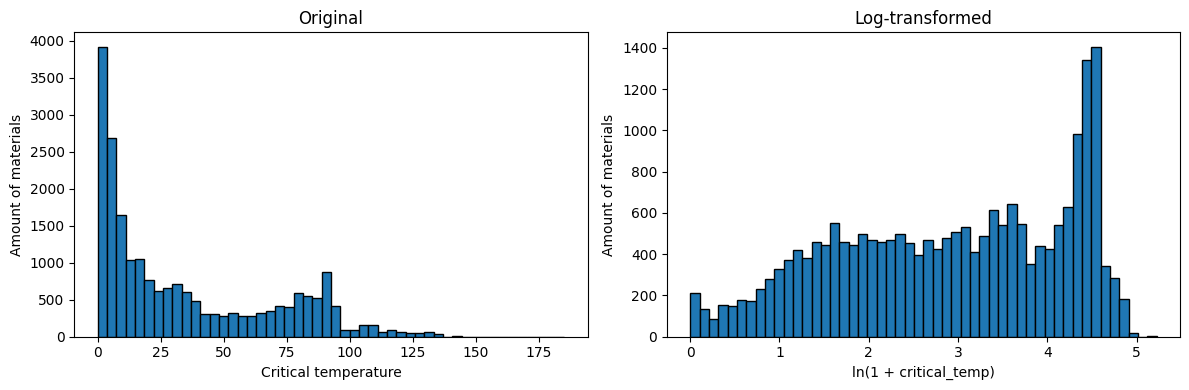

In [26]:
target = data["critical_temp"]
log_target = np.log1p(target)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(target, bins=50, edgecolor="black")
axes[0].set_title("Original")
axes[0].set_xlabel("Critical temperature")
axes[0].set_ylabel("Amount of materials")

axes[1].hist(log_target, bins=50, edgecolor="black")
axes[1].set_title("Log-transformed")
axes[1].set_xlabel("ln(1 + critical_temp)")
axes[1].set_ylabel("Amount of materials")

plt.tight_layout()
plt.show()

Looking at the original plot we can see that most of the materials is represented in the start of the plot, but then it drops. The tallest bar contains around 4000 materials within its temperature interval.

While the log transformed plot spreads out the lower temperture observaations, which gives a better distribution of the data, Here the tallest bar contains around 1400 materials.


Even though the log-transformed target looks more balanced, I chose to use the raw critical_temp for the regression models in the rest of this assignment. This keeps the results in kelvin, without needing to convert predictions back from log-scale each time. I chose to do this to make it a bit simpler for me.

## 1.2 Correlation Analysis
### Q1.2.1

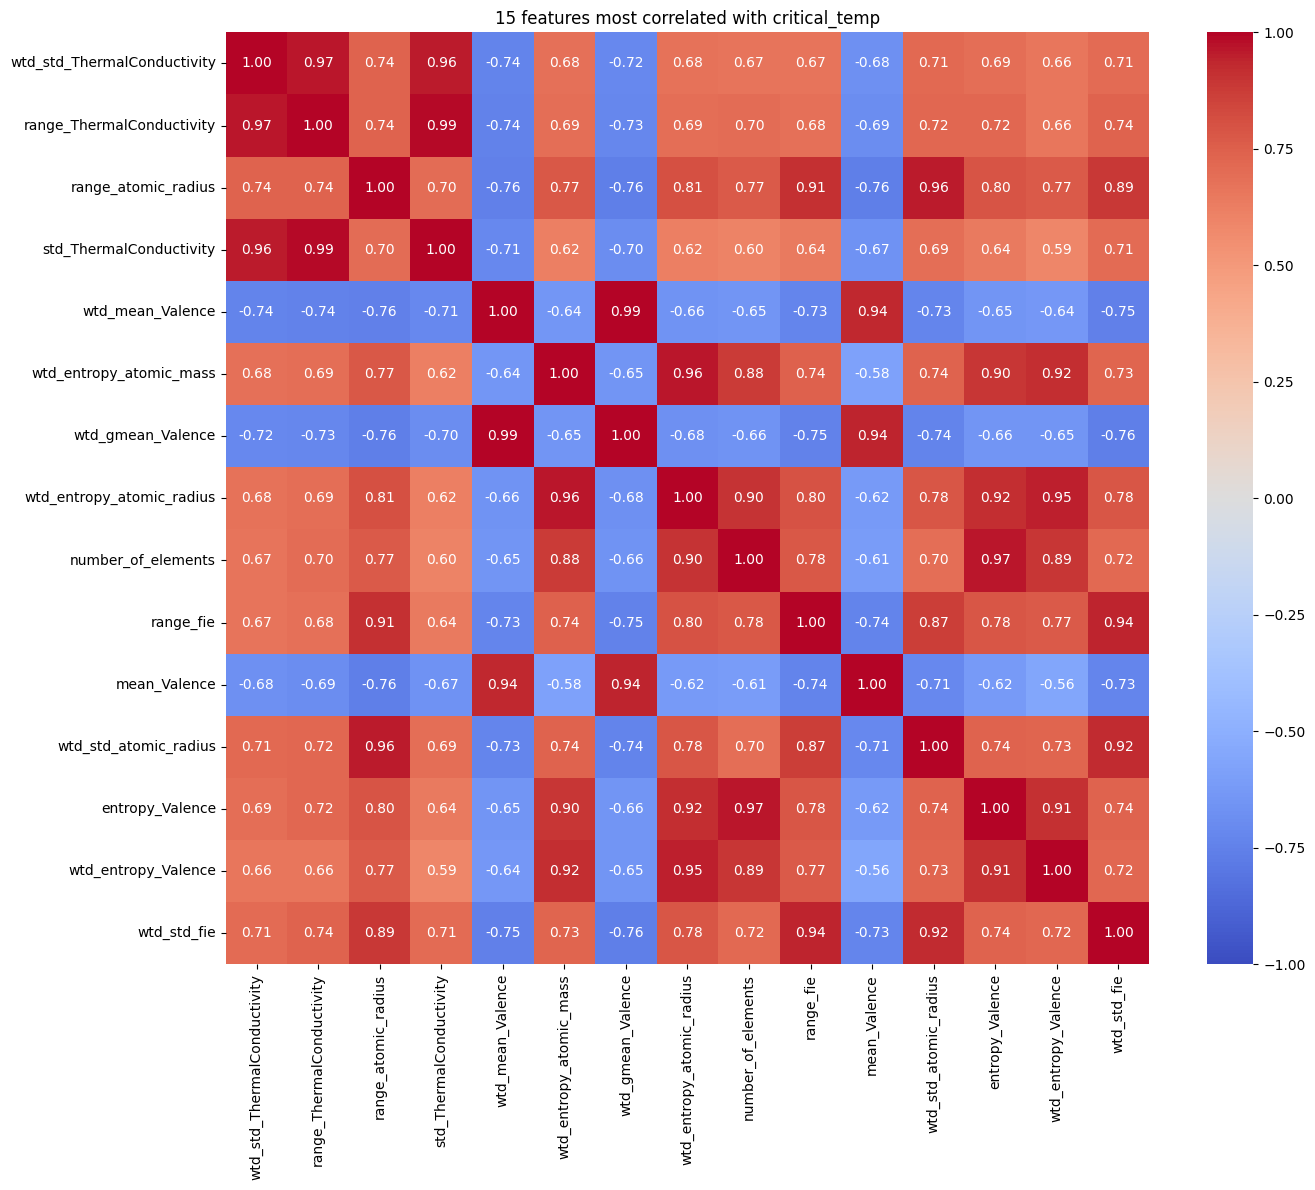

In [27]:
# Create correlation matrix
corr_matrix = data.corr(numeric_only=True)
target_corr = corr_matrix["critical_temp"].drop("critical_temp")

# Get the 15 most correlated features
top_15 = target_corr.abs().sort_values(
    ascending=False
).head(15).index

top_15_corr = corr_matrix.loc[top_15, top_15]

# Plot the heatmap
plt.figure(figsize=(14, 12))

sns.heatmap( top_15_corr, annot=True,
            fmt=".2f", cmap="coolwarm",
             vmin=-1, vmax=1, center=0)

plt.title("15 features most correlated with critical_temp")
plt.tight_layout()
plt.show()


### Q1.2.2


In [28]:
target_corr = corr_matrix["critical_temp"].drop("critical_temp")

sorted_corr = target_corr.sort_values(ascending=False)

# Strongest positive correaltion
display(sorted_corr.head(1))
# Strongest negative correlation
display(sorted_corr.tail(1))

,critical_temp
wtd_std_ThermalConductivity,0.721271


,critical_temp
wtd_mean_Valence,-0.632401


The variable with the strongest positive correaltion is `wtd_std_ThermalConductivity`.

The variable with the strongst negative correalation is `wtd_mean_Valence`.

### Q1.2.3


In [29]:
feature_corr = corr_matrix.drop(
    index="critical_temp", columns="critical_temp"
)

upper_triangle = np.triu(
    np.ones(feature_corr.shape, dtype=bool), k=1
)

pairs = feature_corr.where(upper_triangle).stack()

high_corr = pairs[pairs.abs() > 0.9]

display(high_corr.sort_values(key=abs, ascending=False).head(5))

,,0
entropy_fie,entropy_atomic_radius,0.997739
wtd_mean_Valence,wtd_gmean_Valence,0.994939
entropy_fie,entropy_Valence,0.992726
wtd_mean_fie,wtd_gmean_fie,0.992331
mean_Valence,gmean_Valence,0.989911


Looking at the table with we have a high scores on the corelation all of the top five are around 0.99. This can mean that a lot of the infromation overlaps.

This can make it harder for a linear regression model to determine their separate contributuions to the prediction. One way to address this problem is to remove one feature which have a high correlation with another, and check wheter the predcition performance change.

### Q1.2.4


In [30]:
weak_pred = sorted_corr.abs().idxmin()

print("Feature: ", weak_pred,
      ", Correlation:", sorted_corr[weak_pred])

Feature:  gmean_fie , Correlation: -0.025103248872684076


By looking at our findings in Q1.2.2, we can see find the feature with a strong correlation with `critical_temp`. There we will see that `wtd_std_ThermalConductivity` will work as a strong predictator because it has a correlation of around `0.72`. This means that materials with a higher values of this feature tend to have a higher critical temperature.

By using `abs()` and `idxmin()`, we find the feature with the correlation closest to zero. This is `gmean_fie`, with a correlation of around `−.025`. I expect this to be a weak predictor because the correlation suggests very little linear relationship with `critical_temp`.


## 1.3 Linear Regression

### Q1.3.1

Fit a simple linear regression model using gradient descent to predict critical_temp
using only the weak predictor selected in Q1.2.4. Standardize the feature before
running gradient descent and explain why this matters here

In [31]:
X_gmean = data[["gmean_fie"]].to_numpy()
Y = data[["critical_temp"]].to_numpy()

scaler_gmean = StandardScaler()
gmean_scaled = scaler_gmean.fit_transform(X_gmean)

m = len(Y)
X_gmean_b = np.c_[np.ones((m, 1)), gmean_scaled]

eta = 0.1
n_epochs = 1000

np.random.seed(42)
theta_gmean = np.random.randn(2, 1)

for epoch in range(n_epochs):
    gradients = (2 / m) * X_gmean_b.T @ (X_gmean_b @ theta_gmean - Y)
    theta_gmean = theta_gmean - eta * gradients

By standardizing the features we subtract the mean and divides by the standard devitation. This gives the feature a mean of 0 and a standard deviation of 1, really we are only changing the scale of the values. By doing this it helps gradient descent make more stable updates, since large values can create large updates. Then gradient decent can overshoot the solution.

### Q1.3.2

In [32]:
X_thermal = data[["wtd_std_ThermalConductivity"]].to_numpy()

scaler_thermal = StandardScaler()
thermal_scaled = scaler_thermal.fit_transform(X_thermal)

X_thermal_b = np.c_[np.ones((m, 1)), thermal_scaled]

np.random.seed(42)
theta_thermal = np.random.randn(2, 1)

for epoch in range(n_epochs):
    gradients = (2 / m) * X_thermal_b.T @ (X_thermal_b @ theta_thermal - Y)
    theta_thermal = theta_thermal - eta * gradients

### 1.3.3

In [33]:
print("gmean_fie")
print("Intercept:", theta_gmean[0,0])
print("Coefficient:", theta_gmean[1,0])
print("---------------------------------------")
print("wtd_std_ThermalConductivity")
print("Thermal Intercept:", theta_thermal[0,0])
print("Thermal Coefficient:", theta_thermal[1,0])

gmean_fie
Intercept: 34.42121913535246
Coefficient: -0.8598755648160568
---------------------------------------
wtd_std_ThermalConductivity
Thermal Intercept: 34.42121913535247
Thermal Coefficient: 24.706099985068654


Looking at the two models the intercept are the same for both around 34.32 K, this was expected since both are using the `critical_temp`.

The coefficent is different, `gmean_fie` coefficent is around -0.85, and `wtd_std_ThermalConductivity` is around 24.71. This means that the weak model decrease, and the stronger model increases much more when the thermal conducitvity value increases.



### Q1.3.4



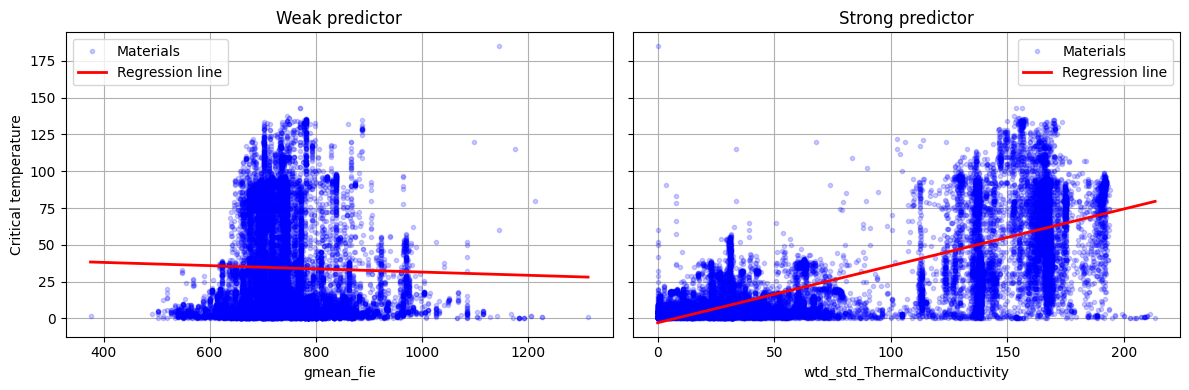

In [48]:
# Endpoints and predictions for the weak model
gmean_endpoints = np.array([[X_gmean.min()], [X_gmean.max()]])
gmean_endpoints_scaled = scaler_gmean.transform(gmean_endpoints)
gmean_endpoints_b = np.c_[np.ones((2, 1)), gmean_endpoints_scaled]

gmean_predictions = gmean_endpoints_b @ theta_gmean

# Endpoints and predictions for the strong model
thermal_endpoints = np.array([[X_thermal.min()], [X_thermal.max()]])
thermal_endpoints_scaled = scaler_thermal.transform(thermal_endpoints)
thermal_endpoints_b = np.c_[np.ones((2, 1)), thermal_endpoints_scaled]

thermal_predictions = thermal_endpoints_b @ theta_thermal

# Show both models side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].plot(X_gmean, Y, "b.", alpha=0.2, label="Materials")
axes[0].plot(gmean_endpoints, gmean_predictions, "r-",
             linewidth=2, label="Regression line")
axes[0].set_xlabel("gmean_fie")
axes[0].set_ylabel("Critical temperature")
axes[0].set_title("Weak predictor")
axes[0].legend()
axes[0].grid()

axes[1].plot(X_thermal, Y, "b.", alpha=0.2, label="Materials")
axes[1].plot(thermal_endpoints, thermal_predictions, "r-",
             linewidth=2, label="Regression line")
axes[1].set_xlabel("wtd_std_ThermalConductivity")
axes[1].set_title("Strong predictor")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

Looking at the regression line for `gmean_fie` it is almost flat and decrerases slightly. In the middle of the plot arround x value 800, there is a large varition in the actual temperature. Therefore  the regresion line is weak and it does not fit with the data.

The `wtd_std_ThermalConductivity` line follows an upward trend, but there are still a lot of points far from it. The line is still works better as a predictor, which is expected since it has a higher correaltion with `critical_temp` than the `gmean_fie`have.

## 1.4 Train-Test Split

In [35]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score

# store the actualtemperatures and simple regresiion
actual_simple = []
predicted_simple = []

# store the results
results_gmean = []
results_thermal = []

# fold and split the data
folds = KFold(n_splits=5, shuffle=True, random_state=42)
splits = list(folds.split(data))

# train the model
def train_linear_regression_model(X, Y, amount_features, eta):
  n_epochs = 1000

  m = len(X)
  X_b = np.c_[np.ones((m,1)), X]

  np.random.seed(42)
  theta = np.random.randn(amount_features, 1)

  for epoch in range(n_epochs):
    gradients = (2 / m) * X_b.T @ (X_b @ theta - Y)
    theta = theta - eta * gradients

  return theta

# fills the training set and test sets with data in 5 different folds
for traing_set, test_set in splits:
  # split the feature values
  X_gmean_train = X_gmean[traing_set]
  X_gmean_test = X_gmean[test_set]

  X_thermal_train = X_thermal[traing_set]
  X_thermal_test = X_thermal[test_set]

  Y_train = Y[traing_set]
  Y_test = Y[test_set]

  # stanadrdize the data
  scaler_gmean = StandardScaler()
  X_gmean_train_scaled = scaler_gmean.fit_transform(X_gmean_train)
  X_gmean_test_scaled = scaler_gmean.transform(X_gmean_test)

  scaler_thermal = StandardScaler()
  X_thermal_train_scaled = scaler_thermal.fit_transform(X_thermal_train)
  X_thermal_test_scaled = scaler_thermal.transform(X_thermal_test)

  # Train the weak model
  theta_gmean = train_linear_regression_model(
      X_gmean_train_scaled, Y_train, 2, 0.1
  )

  # Train the strong model
  theta_thermal = train_linear_regression_model(
      X_thermal_train_scaled, Y_train, 2, 0.1
  )

  # Predictions
  X_gmean_test_b = np.c_[np.ones((len(Y_test), 1)), X_gmean_test_scaled]

  X_thermal_test_b = np.c_[np.ones((len(Y_test), 1)), X_thermal_test_scaled]

  predictions_gmean = X_gmean_test_b @ theta_gmean

  predictions_thermal = X_thermal_test_b @ theta_thermal

  # for the comparison plot
  actual_simple.extend(Y_test.ravel())
  predicted_simple.extend(predictions_thermal.ravel())

  # Evaluate the model on the test set
  mse_gmean = mean_squared_error(Y_test, predictions_gmean)
  mse_thermal = mean_squared_error(Y_test, predictions_thermal)

  rmse_gmean = np.sqrt(mse_gmean)
  rmse_thermal = np.sqrt(mse_thermal)

  r2_gmean = r2_score(Y_test, predictions_gmean)
  r2_thermal = r2_score(Y_test, predictions_thermal)

  results_gmean.append([mse_gmean, rmse_gmean, r2_gmean])
  results_thermal.append([mse_thermal, rmse_thermal, r2_thermal])


### Q1.4.1

In [36]:
thermal_results = pd.DataFrame(
    results_thermal,
    columns = ["MSE", "RMSE", "R2"],
    index = range(1, 6)
)

thermal_results.index.name = "Fold"
display(thermal_results)

,MSE,RMSE,R2
Fold,,,
1,544.675849,23.338291,0.526813
2,584.161911,24.169442,0.513818
3,550.312673,23.458744,0.508203
4,571.186088,23.899500,0.524414
5,565.574480,23.781810,0.525200


The predicator performs the similar across the 5 different folds. The root mean squared error performs best at fold 1 getting 23.33, and worst on fold 2 getting 24.16.

The $R^2$ value ranges between 0.508 to 0.527. This means that the model reduces squared prediciton error by 51-53% compared to predicting the test sets average temeprature. Therefore the feature `wtd_std_ThermalConductivit` helps making the prediction, but it will still be a off and create errors.

### Q1.4.2

In [37]:
thermal_results = pd.DataFrame(
    results_gmean,
    columns = ["MSE", "RMSE", "R2"],
    index = range(1, 6)
)

thermal_results.index.name = "Fold"
display(thermal_results)

,MSE,RMSE,R2
Fold,,,
1,1150.714033,33.922176,0.000318
2,1202.109922,34.671457,-0.000483
3,1120.294739,33.470804,-0.001171
4,1200.917864,34.654262,0.000082
5,1190.469222,34.503177,0.000601


The predicator performs the similar across the 5 different folds. The root mean squared error performs best at fold 3 getting 33.47, and worst on fold 5 getting 34.67.

All the R2 values are close to zero on all the folds. These numbers mean that the model perofrms almost the same as predicting the test sets average temperature for evry material. In fold 2 and 3 both the $R^2$ valeus are negative meaning it scored worse than the averaeg prediction.

This does not come as a suprice since `gmean_fie` has almost zero linear correlation with `critical_temp`.

### Q1.4.3
I think the model underfits, beause it only uses one feature. The model also assumes that the relationship with the cirtical temeprature is a straig line. Looking at the plot from Q1.3.4 we can see that it shows a lot of points far from the regression line.

I belive that adding more useful features, with a a high correaltion to `critical_tempe`, will provide better results.

### Q1.4.4


In [38]:
summary = pd.DataFrame({
    "Strong Predictator Mean": np.mean(results_thermal, axis=0),
    "Strong Predictator Variance": np.var(results_thermal, axis=0),
    "Weak Predictator Mean": np.mean(results_gmean, axis=0),
    "Weak Predictator Variance": np.var(results_gmean, axis=0)
}, index = ["MSE", "RMSE", "R^2"])

display(summary)

,Strong Predictator Mean,Strong Predictator Variance,Weak Predictator Mean,Weak Predictator Variance
MSE,563.182200,203.608653,1172.901156,1.041286e+03
RMSE,23.729557,0.090308,34.244375,2.239217e-01
R^2,0.519690,0.000054,-0.000131,3.977987e-07


The strong predictor performs better on average, with a mean RMSE of 23.73 K compared with 34.24 K for the weak predictor. The strong predictor also has a higher mean R² of approximately 0.52, while the weak predictor’s mean R² is almost zero. This tells us that the strong model performs better than predicting the test set’s average temperature, while the weak model provides almost no improvement.

The strong predictor also has lower variance for both MSE and RMSE. Its RMSE variance is approximately 0.090, compared with 0.224 for the weak predictor, showing that its error size changes less between folds.

The weak predictor has lower R² variance, but its R² values stay close to zero. This means it consistently performs about the same as predicting the test set’s average temperature.

Overall, the strong predictor gives better predictions across the five folds.


## 1.5 Multiple Linear Regresiion

### Q1.5.1

In [39]:
X_all = data.drop(columns=["critical_temp"]).to_numpy()
Y = data[["critical_temp"]].to_numpy()

# store the acractual ial temperatures and simple regression
actual_multiple = []
predicted_multiple = []

# store the results
results_all = []

for train_indices, test_indices in splits:
    # Split the data
    X_all_train = X_all[train_indices]
    X_all_test = X_all[test_indices]

    Y_train = Y[train_indices]
    Y_test = Y[test_indices]

    # Standardize
    scaler_all = StandardScaler()
    X_all_train_scaled = scaler_all.fit_transform(X_all_train)
    X_all_test_scaled = scaler_all.transform(X_all_test)

    # Train the model
    theta_all = train_linear_regression_model(
        X_all_train_scaled, Y_train, 82, 0.01
    )

    # Predictions
    X_all_test_b = np.c_[
        np.ones((len(Y_test), 1)), X_all_test_scaled
    ]

    predictions_all = X_all_test_b @ theta_all

    # for the comparison plot
    actual_multiple.extend(Y_test.ravel())
    predicted_multiple.extend(predictions_all.ravel())

    # Evaluate fold
    mse_all = mean_squared_error(Y_test, predictions_all)
    rmse_all = np.sqrt(mse_all)
    r2_all = r2_score(Y_test, predictions_all)

    results_all.append([mse_all, rmse_all, r2_all])

display(pd.DataFrame(
    results_all,
    columns=["MSE", "RMSE", "R2"],
    index=range(1, 6)
))

print()

summary = pd.DataFrame({
    "Mean": np.mean(results_all, axis=0),
    "Variance": np.var(results_all, axis=0),
}, index = ["MSE", "RMSE", "R^2"])

display(summary)

,MSE,RMSE,R2
1,333.804025,18.270304,0.710008
2,361.657992,19.017308,0.699002
3,346.629566,18.617990,0.690228
4,351.721259,18.754233,0.707147
5,343.447411,18.532334,0.711676


,Mean,Variance
MSE,347.452050,84.603429
RMSE,18.638434,0.060830
R^2,0.703612,0.000064


### Q1.5.2

The multiple linear regression model performs better than the simple linear regression model using the strong predictor across all five folds.

The mean $R^2$ increases from 0.52 to 0.7, an improvement of around 0.18. The mean RMSE decreases from 23.73 to 18.64, meaning the predcitions are closer to actual critical temperature. The MSE also decreases from 569.18 to 347.45.

The mutliple regression models has a $R^2$ variance of around 0.000064, but the RMSE and MSE variance is both lower. Overall using all the 81 features give a better predictions than only using one strong predictator.


### Q1.5.3

Plot (iii) Predicted vs Actual (perfomance)

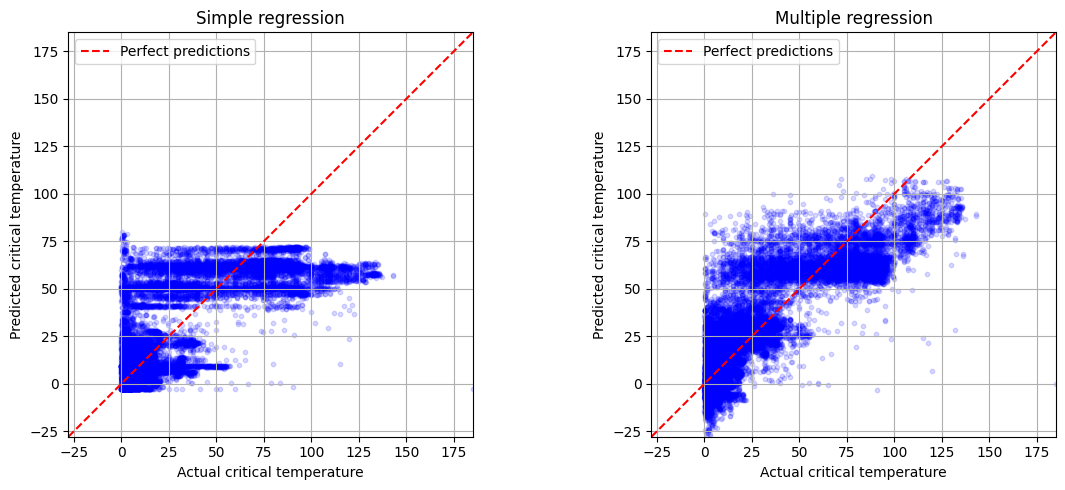

In [40]:
import matplotlib.pyplot as plt

lower = min(
    min(actual_simple), min(predicted_simple),
    min(actual_multiple), min(predicted_multiple)
)
upper = max(
    max(actual_simple), max(predicted_simple),
    max(actual_multiple), max(predicted_multiple)
)

fig, axes = plt.subplots(
    1, 2, figsize=(12, 5),
    sharex=True, sharey=True
)

# plot the simple regression
axes[0].scatter(
    actual_simple, predicted_simple,
    s=10, alpha=0.15, color="blue"
)
axes[0].set_title("Simple regression")

# plot the multiple regression regression
axes[1].scatter(
    actual_multiple, predicted_multiple,
    s=10, alpha=0.15, color="blue"
)
axes[1].set_title("Multiple regression")

# add a line representing where the perfect predictions would fall
for ax in axes:
    ax.plot(
        [lower, upper], [lower, upper],
        "r--", label="Perfect predictions"
    )
    ax.set_xlabel("Actual critical temperature")
    ax.set_xlim(lower, upper)
    ax.set_ylim(lower, upper)
    ax.set_aspect("equal", adjustable="box")
    ax.grid()
    ax.legend()

axes[0].set_ylabel("Predicted critical temperature")
axes[1].set_ylabel("Predicted critical temperature")
axes[1].tick_params(axis="y", labelleft=True)

plt.tight_layout()
plt.show()

### Q.1.5.4
The multi linear regression model performs better. Looking at the MSE, RMSE and $R^2$ it outperforms the single linear regression model. Using all the 81 features it gives the model gets more information to use, instead of only using one strong predictor.

Looking at the graph and see the predictions of the simple regression it does not predict the critical temepetrute well, and does not follow the line. Wheras the multiple regression model are generally closer to the perfect prediction line, although it remains still a lot of errors. It still performs far better then the single regression model.

I would not fully trust the individual cofficients, because of multicollinearity. From Q1.2.3 i found out that there are several features wich were highly correlated, so they provide overlapping information. This can result in that the model have difficulties seperating their contributions.  Becuase of this small changes in the training data can lead to large changes in the individual coefficients, even when the predcitions remain similar. Therefore good predictions do not necessarli mean that each coefficient relaibly shows the contribution of its feature.

# Exercise 2

### Q2.1

In [41]:
from sklearn.ensemble import RandomForestRegressor

train_indices, test_indices = splits[0]

X_all_train = X_all[train_indices]
Y_train = Y[train_indices]

# create forest
forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
)

# train the forest
forest_model.fit(X_all_train, Y_train.ravel())

feature_names = data.drop(columns=["critical_temp"]).columns

ranked_features = sorted(
    zip(forest_model.feature_importances_, feature_names),
    reverse=True
)

display(pd.DataFrame(
    ranked_features[:10],
    columns=["Importance", "Feature"]
))

,Importance,Feature
0,0.536232,range_ThermalConductivity
1,0.126107,wtd_gmean_ThermalConductivity
2,0.023527,std_atomic_mass
3,0.019155,wtd_gmean_Valence
4,0.012611,wtd_entropy_ThermalConductivity
5,0.011433,wtd_mean_Valence
6,0.011010,mean_Density
7,0.010945,wtd_range_Valence
8,0.010356,std_Density
9,0.010136,gmean_ElectronAffinity


After using `RandomForesRegressor` and train it on the data, it shows that `range_ThermalConducitivity` is the most suitbale feauture to use for predicting the `cirtical_temp` getting a score of 0.536. This is followed by `wtd_gmean_ThermalConductivity` at 0.126 and `std_atomic_mass` at 0.024.

However several features are highly correlated. Therefore a low importance score does not mean a feature contains less useful information.

### Q.2

#### a)

In [44]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

X_top10 = data[[
    "range_ThermalConductivity",
    "wtd_gmean_ThermalConductivity",
    "std_atomic_mass",
    "wtd_gmean_Valence",
    "wtd_entropy_ThermalConductivity",
    "wtd_mean_Valence",
    "mean_Density",
    "wtd_range_Valence",
    "std_Density",
    "gmean_ElectronAffinity"
]].to_numpy()

# Store the reuslt
results_poly = []

# fills the training set and test sets with data in 5 different folds
for train_indices, test_indices in splits:
  X_train = X_top10[train_indices]
  X_test = X_top10[test_indices]

  Y_train = Y[train_indices]
  Y_test = Y[test_indices]

  poly = PolynomialFeatures(degree = 2, include_bias = False)

  X_train_poly = poly.fit_transform(X_train)
  X_test_poly = poly.transform(X_test)

  # Standardize the data
  scaler_poly = StandardScaler()

  X_train_scaled = scaler_poly.fit_transform(X_train_poly)
  X_test_scaled = scaler_poly.transform(X_test_poly)

  # Train the model
  poly_model = LinearRegression()
  poly_model.fit(X_train_scaled, Y_train)

  # Predict using the test set
  predictions_poly = poly_model.predict(X_test_scaled)

  # Evaluate the model
  mse_poly = mean_squared_error(Y_test, predictions_poly)
  rmse_poly = np.sqrt(mse_poly)
  r2_poly = r2_score(Y_test, predictions_poly)

  results_poly.append([mse_poly, rmse_poly, r2_poly])

display(pd.DataFrame(
    results_poly,
    columns=["MSE", "RMSE", "R2"],
    index=range(1, 6)
))

print()

display(pd.DataFrame({
    "Average for all 5 folds": np.mean(results_poly, axis = 0)
}, index = ["MSE", "RMSE", "R2"]))

print()

print("Parameters: ", poly_model.coef_.size)

,MSE,RMSE,R2
1,362.146503,19.030147,0.685386
2,392.051668,19.800295,0.673706
3,380.922330,19.517232,0.659582
4,385.856859,19.643240,0.678725
5,384.529627,19.609427,0.677187


,Average for all 5 folds
MSE,381.101397
RMSE,19.520068
R2,0.674917



Parameters:  65


Across all the five folds average it has a MSE of 381.10, RMSE of 19.52 and $R^2$ of 0.67. It improves the performance when comparing it to the linear regression i mad ein task 1.3. However it does not outperform the multiple linear regression which used all the 81 features.

Its improvement compared to the single linear regression model is probably because the polynomial model can capture nonlinear relationships and interactions between the features. The 10 fetatures are expanded into 65 features, which gives the model 66 parameteres including the intercept.

The increase of parameters can also create a risk of overfitting. Because several features are correlated, the model has more ways to fit the training data using unstable overlapping numbers which can fit noise instead of the real pattern.

#### b)

In [45]:
from sklearn.linear_model import RidgeCV, LassoCV

results_ridge = []
results_lasso = []

alpha_ridge = []
alpha_lasso = []

lasso_coefs = []

alpha_values = np.logspace(-4, 3, 30)

for train_indices, test_indices in splits:
    # Split data
    X_train = X_all[train_indices]
    X_test = X_all[test_indices]

    Y_train = Y[train_indices]
    Y_test = Y[test_indices]

    # Standardize
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Ridge regression
    ridge_model = RidgeCV(
        alphas=alpha_values,
        cv = 5,
        scoring = "neg_mean_squared_error"
    )

    ridge_model.fit(X_train_scaled, Y_train.ravel())

    alpha_ridge.append(ridge_model.alpha_)

    # Predict using the test set
    ridge_predictions = ridge_model.predict(X_test_scaled)

    # Evaluate the model
    mse_ridge = mean_squared_error(Y_test, ridge_predictions)
    rmse_ridge = np.sqrt(mse_ridge)
    r2_ridge = r2_score(Y_test, ridge_predictions)

    results_ridge.append([
        mse_ridge,
        rmse_ridge,
        r2_ridge
    ])

    # Lasso
    # uses mse for comparing alpha values
    lasso_model = LassoCV(
        alphas=alpha_values,
        cv = 5,
    )

    lasso_model.fit(X_train_scaled, Y_train.ravel())

    lasso_coefs.append(lasso_model.coef_)

    alpha_lasso.append(lasso_model.alpha_)

    # Predict using the test set
    lasso_predictions = lasso_model.predict(X_test_scaled)

    mse_lasso = mean_squared_error(Y_test, lasso_predictions)
    rmse_lasso = np.sqrt(mse_lasso)
    r2_lasso = r2_score(Y_test, lasso_predictions)

    results_lasso.append([
        mse_lasso,
        rmse_lasso,
        r2_lasso
    ])

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 16790.958928153384, tolerance: 1361.2988761248068
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 161825.82227570005, tolerance: 1361.2988761248068
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 326739.2960654604, tolerance: 1361.2988761248068
  model = cd_fast.enet_coordinate_descent_gram(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:681: Convergen

In [46]:
# Ridge: Results for each fold
print("Ridge: Results for each fold")
display(pd.DataFrame(
    results_ridge,
    columns=["MSE", "RMSE", "R2"],
    index=range(1, 6)
))

print()

# Ridge: Mean and variance across folds
print("Ridge: Mean and variance across folds")
display(pd.DataFrame({
    "Mean": np.mean(results_ridge, axis=0),
    "Variance": np.var(results_ridge, axis=0)
}, index=["MSE", "RMSE", "R2"]))

print()

print("Alphas used for each fold")
display(alpha_ridge)

print()

# Lasso: Results for each fold
print("Lasso: Results for each fold")
display(pd.DataFrame(
    results_lasso,
    columns=["MSE", "RMSE", "R2"],
    index=range(1, 6)
))

print()

# Lasso: Mean and variance across folds
print("Lasso: Mean and variance across folds")
display(pd.DataFrame({
    "Mean": np.mean(results_lasso, axis=0),
    "Variance": np.var(results_lasso, axis=0)
}, index=["MSE", "RMSE", "R2"]))

print()

print("Alphas used for each fold")
display(alpha_lasso)

print()

# Summary of lasso features that where dropped
feature_names = data.drop(columns=["critical_temp"]).columns

lasso_coefs = np.array(lasso_coefs)

zero_counts = (lasso_coefs == 0).sum(axis=0)

eliminated = pd.DataFrame({
    "Feature": feature_names,
    "Times zeroed (out of 5 folds)": zero_counts,
    "Mean coefficient": lasso_coefs.mean(axis=0)
}).sort_values("Times zeroed (out of 5 folds)", ascending=False)

display(eliminated[eliminated["Times zeroed (out of 5 folds)"] > 0])

Ridge: Results for each fold


,MSE,RMSE,R2
1,304.059662,17.437307,0.735848
2,321.779497,17.938213,0.732192
3,312.030818,17.664394,0.721148
4,317.456479,17.817308,0.735677
5,309.747904,17.599656,0.739967



Ridge: Mean and variance across folds


,Mean,Variance
MSE,313.014872,37.676749
RMSE,17.691376,0.030096
R2,0.732966,0.000041



Alphas used for each fold


...


Lasso: Mean and variance across folds


,Mean,Variance
MSE,314.004201,32.518386
RMSE,17.719433,0.025904
R2,0.732123,0.000037



Alphas used for each fold


[np.float64(0.008531678524172814),
 np.float64(0.004893900918477494),
 np.float64(0.0001),
 np.float64(0.008531678524172814),
 np.float64(0.008531678524172814)]

,Feature,Times zeroed (out of 5 folds),Mean coefficient
4,wtd_gmean_atomic_mass,3,1.928369
14,wtd_gmean_fie,3,-0.919174
3,gmean_atomic_mass,3,-1.869907
11,mean_fie,3,1.900007
45,entropy_ElectronAffinity,3,0.237822
13,gmean_fie,2,-1.919742
8,wtd_range_atomic_mass,2,0.159607
60,wtd_std_FusionHeat,2,0.037535
72,wtd_mean_Valence,1,0.384669
79,std_Valence,1,-0.255516


Ridge regression shrinks all the 81 coefficients toward zero but keeps the features in the model. This spreads out the weight more evenly between correlated features instead of letting one dominate. Lasso can shrink the coeffcient down to zero, which elimantes them from the model entirely.

Looking at the table for features that were elimanted the most consistent ones were:


*   `wtd_gmean_atomic_mass`, elimanted 3 out ouf 5 folds
*   `wtd_gmean_fie`, elimanted 3 out ouf 5 folds
* `gmean_atomic_mass`, elimanted 3 out ouf 5 folds
* `mean_fie`, elimanted 3 out ouf 5 folds

This means that the Lasso feature selection is unstable rather than settling on one fixed subset of features to elimante.

This also agrees with the multicollinear pairs found in Q1.2.3. Eg. `wtd_mean_fie` and `wtd_gmean_fie` were one of the highly correlated pairs, with a correaltion of 0.992, and in `wtd_gmean_fie` was one of the features which got zeroed in 3/5 folds, whil `wtd_mean_fie` was never zeroed down. The same happend for `wtd_mean_Valence` and `wtd_gmean_Valence`, but then `wtd_mean_Valence` was only zeroed in 1/5 folds.

Not every eliminated feature was part of the strongest correlated pairs. For example, `entropy_ElectronAffinity` was eliminated in 3 folds, but it was not among the top five correlated pairs from Q1.2.3. This may be because it has weak predictive information or because its information overlaps with other features that were not among the top five pairs. Also, `gmean_fie` was eliminated in 2 folds and had previously been identified as a weak predictor in Q1.2.4.

#### c)

In [47]:
from sklearn.ensemble import RandomForestRegressor

results_forest = []

for train_indices, test_indices in splits:

    # Split the data
    X_train = X_all[train_indices]
    X_test = X_all[test_indices]

    Y_train = Y[train_indices]
    Y_test = Y[test_indices]

    # Create the nonlinear model
    forest_model = RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )

    # Train using only the training data
    forest_model.fit(X_train, Y_train.ravel())

    # Predict the test data
    forest_predictions = forest_model.predict(X_test)

    # Evaluate the model
    mse_forest = mean_squared_error(
        Y_test,
        forest_predictions
    )

    rmse_forest = np.sqrt(mse_forest)

    r2_forest = r2_score(
        Y_test,
        forest_predictions
    )

    results_forest.append([
        mse_forest,
        rmse_forest,
        r2_forest
    ])


# Results for each fold
display(pd.DataFrame(
    results_forest,
    columns=["MSE", "RMSE", "R2"],
    index=range(1, 6)
))


# Mean and variance across folds
display(pd.DataFrame({
    "Mean": np.mean(results_forest, axis=0),
    "Variance": np.var(results_forest, axis=0)
}, index=["MSE", "RMSE", "R2"]))

,MSE,RMSE,R2
1,80.615155,8.978594,0.929966
2,94.993461,9.746459,0.920940
3,85.108933,9.225450,0.923941
4,89.750056,9.473651,0.925272
5,87.982310,9.379889,0.926139


,Mean,Variance
MSE,87.689983,22.877030
RMSE,9.360809,0.065247
R2,0.925251,0.000009


For this task i will compare Random Forest with the Mulitple Linear Regression Model from 1.5.

The Random Forest had an average MSE of 87.69 compared with 347.45 for the linear model. Its average RMSE was 9.36, while the linear model had an RMSE of 18.64. The Random Forest also had a higher average $R^2$ value of 0.925 compared with 0.704. This means that the Random Forest predictions were closer to the actual critical temperature.

The Random Forest likely performed better because it can capture nonlinear relationships and interactions between features. Multiple linear regression assumes that the relationship between each feature and critical_temp is a straight line, while Random Forest can model more complex patterns. Therefore, the Random Forest was more suitable for this dataset.